## Import dependencies and dot env file

In [1]:
from dotenv import load_dotenv
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

c:\Users\fkeyu\Documents\MyCode\Python\space-titanic-problem\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

## Loand and split the data

In [3]:
# load the data into a dataframe

raw_train_df = pd.read_csv("../data/raw/train.csv")
raw_train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
X_raw = raw_train_df.drop(columns=['Transported'])
y_raw = raw_train_df['Transported']
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.3, random_state=11)

## Preprocessing

In [5]:
cols_to_drop = ['PassengerId', 'Name']
X_train_processed = X_train.copy()
X_train_processed = X_train_processed.drop(columns=cols_to_drop)

In [6]:
num_cols = X_train_processed.select_dtypes(include=['float64']).columns.to_list()
num_cols


['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [7]:
# convert initial numerical cols to log1p

for i in num_cols:
    X_train_processed[i] = np.log1p(X_train[i])

In [8]:
# convert Cabin to 3 new cols, and drop the original Cabin col

Cabin_list = X_train_processed.Cabin.apply(lambda x: x.split('/') if pd.notnull(x) and x.count('/') == 2 else [None,None,None])

X_train_processed['CabinDeck'] = Cabin_list.apply(lambda x: x[0])
X_train_processed['CabinNum'] = Cabin_list.apply(lambda x: float(x[1]) if x[1] is not None else None)
X_train_processed['CabinSide'] = Cabin_list.apply(lambda x: x[2])

X_train_processed = X_train_processed.drop('Cabin', axis=1)

In [9]:
num_cols = X_train_processed.select_dtypes(include=['number']).columns.to_list()
cat_cols = X_train_processed.select_dtypes(include=['object','str']).columns.to_list()

In [10]:
# Null value imputation for numerical cols 
# One-hot encoding for categorical cols

preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy='median'), num_cols),
            ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
            ],
        remainder="passthrough"
    )

In [11]:
X_train_processed = preprocessor.fit_transform(X_train_processed)

## Training the model

In [12]:
model = LogisticRegression(max_iter=10000, verbose=1, random_state=11)
X_train_processed = X_train_processed.copy()

In [13]:
model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",11
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"verbose verbose: int, default=0For the liblinear and lbfgs solvers set verbose to any positivenumber for verbosity.",1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None


## Preprocess test set and evaluate

### Preprocessing test set

In [14]:
cols_to_drop = ['PassengerId', 'Name']
X_test_processed = X_test.copy()
X_test_processed = X_test_processed.drop(columns=cols_to_drop)

In [15]:
num_cols = X_test_processed.select_dtypes(include=['float64']).columns.to_list()
num_cols

['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [16]:
# convert initial numerical cols to log1p

for i in num_cols:
    X_test_processed[i] = np.log1p(X_test[i])

In [17]:
# convert Cabin to 3 new cols, and drop the original Cabin col

Cabin_list = X_test_processed.Cabin.apply(lambda x: x.split('/') if pd.notnull(x) and x.count('/') == 2 else [None,None,None])

X_test_processed['CabinDeck'] = Cabin_list.apply(lambda x: x[0])
X_test_processed['CabinNum'] = Cabin_list.apply(lambda x: float(x[1]) if x[1] is not None else None)
X_test_processed['CabinSide'] = Cabin_list.apply(lambda x: x[2])

X_test_processed = X_test_processed.drop('Cabin', axis=1)

In [18]:
num_cols = X_test_processed.select_dtypes(include=['number']).columns.to_list()
cat_cols = X_test_processed.select_dtypes(include=['object','str']).columns.to_list()

In [19]:
# Null value imputation for numerical cols 
# One-hot encoding for categorical cols

preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy='median'), num_cols),
            ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
            ],
        remainder="passthrough"
    )

In [20]:
X_test_processed = preprocessor.fit_transform(X_test_processed)

### Making predictions on preprocessed test set

In [21]:
current_threshold = 0.5584083119472486
y_prob = model.predict_proba(X_test_processed)
y_pred = y_prob[:, 1] >= current_threshold

### Evaluation

In [22]:
print(f"accuracy score on test set is: {accuracy_score(y_test, y_pred)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

accuracy score on test set is: 0.7841257668711656
Confusion Matrix:
[[1008  249]
 [ 314 1037]]
Classification Report:
              precision    recall  f1-score   support

       False       0.76      0.80      0.78      1257
        True       0.81      0.77      0.79      1351

    accuracy                           0.78      2608
   macro avg       0.78      0.78      0.78      2608
weighted avg       0.79      0.78      0.78      2608



In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])

# also getting the optimla threshold
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold:", optimal_threshold)

Optimal threshold: 0.5584083119472486


In [24]:
auc_score = roc_auc_score(y_test, y_prob[:,1])
print("ROC AUC Score:", auc_score)

ROC AUC Score: 0.8602331753431707


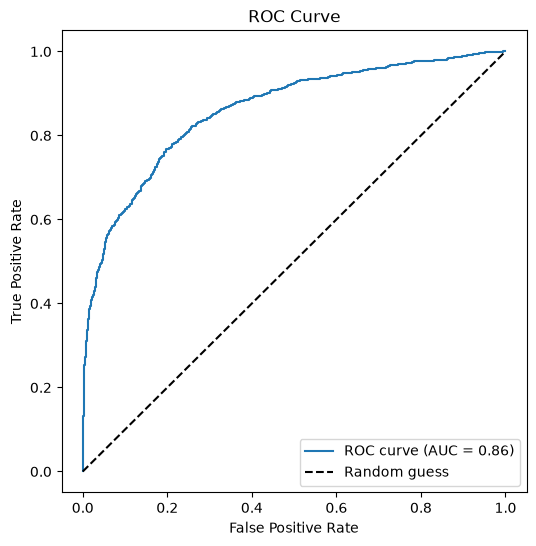

In [25]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()